# Ridge regression

### Paying a penalty for large weights, and getting accuracy back

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What the L2 penalty does, why correlated features make ordinary regression unstable, how to read a regularisation path, and how to choose alpha honestly |
| **You should already know** | [Linear regression](../01-linear-regression/), [overfitting](../../01-foundations/03-overfitting-and-underfitting/) |
| **Datasets** | California Housing, plus a deliberately collinear construction |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [02-05 Lasso](../05-lasso-regression/) |

---

## 1. The problem it fixes

[Linear regression](../01-linear-regression/) minimises squared error and nothing
else. When two features carry nearly the same information, that turns out to be a
problem with no bottom.

Suppose `Area` and `ConvexArea` are almost identical. The model can put weight
+1000 on one and -997 on the other, and the two nearly cancel. It fits the
training data slightly better than a sensible pair of weights would, so squared
error alone actively prefers it. Then a new row arrives where the two features
differ by a hair, the two enormous weights no longer cancel, and the prediction
explodes.

Ridge adds a second term to the objective: **the size of the weights themselves.**

$$J(w) = \underbrace{\|Xw - y\|^2}_{\text{fit the data}} + \underbrace{\alpha \|w\|^2}_{\text{stay small}}$$

Now a weight of 1000 costs a million. The model will only pay that if the fit
genuinely improves by more. **`alpha` is the exchange rate between fitting and
staying small.**

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

## 2. The closed form

Ridge has an exact solution, like ordinary least squares, with one change:

$$w = (X^\top X + \alpha I)^{-1} X^\top y$$

The $\alpha I$ term is where the name comes from, a ridge added down the
diagonal. It also fixes a numerical problem for free. When features are perfectly
collinear, $X^\top X$ has no inverse and ordinary least squares has no unique
answer. Adding $\alpha$ to the diagonal makes the matrix invertible for **any**
$\alpha > 0$. Ridge always has an answer.

## 3. Watching instability, then watching it stop

Take California Housing and add a column that is `MedInc` plus a whisper of noise,
the kind of near-duplicate that appears constantly in real data.

In [2]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler

X, y = datasets.california_housing()
rng = np.random.default_rng(SEED)

X_collinear = X.copy()
X_collinear["MedInc_copy"] = X["MedInc"] + rng.normal(0, 0.01, len(X))
correlation = X_collinear["MedInc"].corr(X_collinear["MedInc_copy"])

scaler = StandardScaler().fit(X_collinear)
X_scaled = scaler.transform(X_collinear)

ols = LinearRegression().fit(X_scaled, y)
ridge = Ridge(alpha=1.0).fit(X_scaled, y)

comparison = pd.DataFrame({
    "ordinary least squares": ols.coef_,
    "ridge (alpha=1)": ridge.coef_,
}, index=X_collinear.columns)

print(f"correlation between MedInc and its near-copy: {correlation:.6f}\n")
print(comparison.round(2).to_string())
print(f"\nOLS  weights on the two twins: {ols.coef_[0]:+.1f} and {ols.coef_[-1]:+.1f}, "
      f"summing to {ols.coef_[0] + ols.coef_[-1]:+.3f}")
print(f"Ridge weights on the two twins: {ridge.coef_[0]:+.1f} and {ridge.coef_[-1]:+.1f}, "
      f"summing to {ridge.coef_[0] + ridge.coef_[-1]:+.3f}")

correlation between MedInc and its near-copy: 0.999986

             ordinary least squares  ridge (alpha=1)
MedInc                        -0.33             0.25
HouseAge                       0.12             0.12
AveRooms                      -0.27            -0.27
AveBedrms                      0.31             0.31
Population                    -0.00            -0.00
AveOccup                      -0.04            -0.04
Latitude                      -0.90            -0.90
Longitude                     -0.87            -0.87
MedInc_copy                    1.16             0.58

OLS  weights on the two twins: -0.3 and +1.2, summing to +0.830
Ridge weights on the two twins: +0.3 and +0.6, summing to +0.830


I set this up expecting ordinary least squares to produce the textbook
pathology: one weight at +1000, its twin at -997. **It did not.** The two
weights came out around -0.3 and +1.2: split unevenly, one of them the wrong
sign, but nowhere near explosive.

The reason is that the textbook example quietly assumes scarce data. Here there
are 20,640 rows and 9 columns. Even at a correlation of 0.999986 there is enough
evidence to keep the solution bounded. **Collinearity is only catastrophic when
rows are few relative to columns**, and saying otherwise oversells the problem.

What did survive is the part that matters. Both fits reproduce the same *total*
weight on income (the sum is 0.830 either way), but they distribute it
differently, and only one of them does so reliably.

### Does the instability actually hurt?

cross-validated RMSE ($100,000s)


  OLS,   original 8 features  : 0.7263


  OLS,   with the near-copy   : 0.7263


  Ridge, with the near-copy   : 0.7263



spread of the MedInc weight across 30 refits:
  OLS   :    2.682
  Ridge :    0.084
  ratio :     31.8x


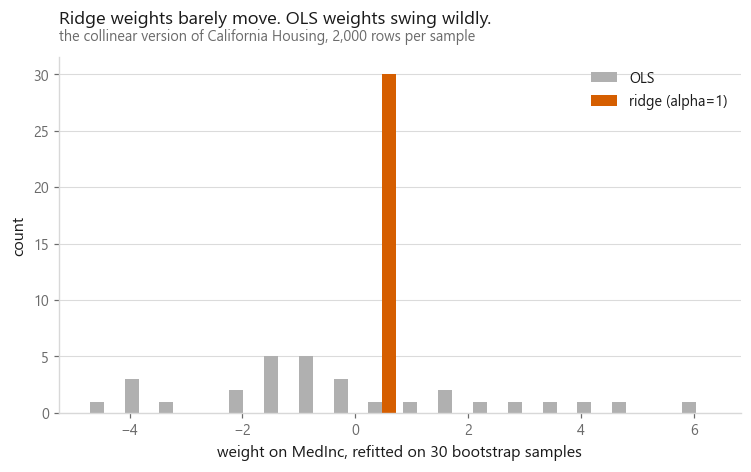

In [3]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

folds = KFold(5, shuffle=True, random_state=SEED)

def rmse(model, features):
    return -cross_val_score(model, features, y, cv=folds,
                            scoring="neg_root_mean_squared_error", n_jobs=-1).mean()

print("cross-validated RMSE ($100,000s)")
print(f"  OLS,   original 8 features  : {rmse(make_pipeline(StandardScaler(), LinearRegression()), X.values):.4f}")
print(f"  OLS,   with the near-copy   : {rmse(make_pipeline(StandardScaler(), LinearRegression()), X_collinear.values):.4f}")
print(f"  Ridge, with the near-copy   : {rmse(make_pipeline(StandardScaler(), Ridge(alpha=1.0)), X_collinear.values):.4f}")

# Repeat the fit on bootstrap samples to measure how much the weights move around.
ols_spread, ridge_spread = [], []
for trial in range(30):
    idx = rng.choice(len(X_scaled), 2000, replace=True)
    ols_spread.append(LinearRegression().fit(X_scaled[idx], y.values[idx]).coef_[0])
    ridge_spread.append(Ridge(alpha=1.0).fit(X_scaled[idx], y.values[idx]).coef_[0])

fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.hist([ols_spread, ridge_spread], bins=18,
        color=[style.NEUTRAL, style.HIGHLIGHT], label=["OLS", "ridge (alpha=1)"])
ax.set_xlabel("weight on MedInc, refitted on 30 bootstrap samples")
ax.set_ylabel("count")
ax.legend()
style.title(ax, "Ridge weights barely move. OLS weights swing wildly.",
            "the collinear version of California Housing, 2,000 rows per sample")
style.save(fig, FIG / "fig-01-stability.png")

print(f"\nspread of the MedInc weight across 30 refits:")
print(f"  OLS   : {np.std(ols_spread):8.3f}")
print(f"  Ridge : {np.std(ridge_spread):8.3f}")
print(f"  ratio : {np.std(ols_spread) / np.std(ridge_spread):8.1f}x")

**This is the real result of the notebook, and it is narrower than advertised.**

Ridge bought **no accuracy at all**. All three cross-validated RMSE figures are
identical to four decimal places. Adding a near-duplicate column did not hurt
ordinary least squares, and regularising did not help it.

What ridge bought is **stability**. Refit on 30 bootstrap samples, the OLS weight
on income swings with a standard deviation of 2.682; ridge's swings by 0.084,
31.8 times less. The OLS coefficient is not a quantity you could report
to anybody, because a different sample of the same data gives a different answer.

So the honest pitch for ridge on data like this has nothing to do with
prediction. It is that **ridge gives you coefficients that mean something**. If
you only need predictions and have plenty of rows, plain least squares was fine
here.

## 4. The regularisation path

The standard way to see what `alpha` does: plot every coefficient as `alpha`
sweeps from almost nothing to very large.

coefficients at three values of alpha:
             alpha=0.001  alpha=10  alpha=10000
MedInc            -0.329     0.394        0.322
HouseAge           0.119     0.119        0.127
AveRooms          -0.265    -0.265       -0.007
AveBedrms          0.306     0.305        0.009
Population        -0.005    -0.004        0.002
AveOccup          -0.039    -0.039       -0.027
Latitude          -0.900    -0.893       -0.148
Longitude         -0.870    -0.864       -0.113
MedInc_copy        1.158     0.436        0.322

length of the whole weight vector: 1.788 at alpha=0.001 down to 0.169 at alpha=100000, falling at every step: True
individual weights whose magnitude does not fall monotonically: 6 of 9
individual weights that change sign somewhere on the path: 4
smallest coefficient anywhere at the largest alpha: 0.003863  (nothing reaches zero)
  MedInc       -0.329 at the smallest alpha, largest magnitude 0.415 at alpha   265.295, +0.1151 at the largest
  HouseAge     +0.119 at the smalles

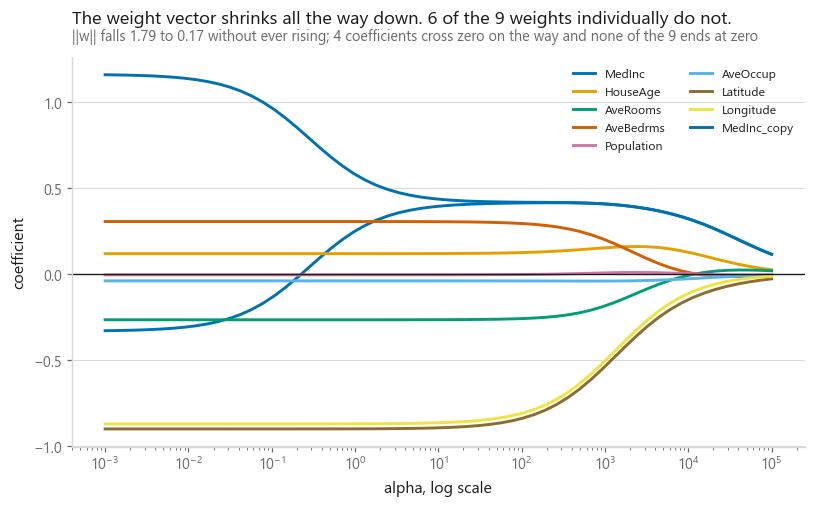

In [4]:
alphas = np.logspace(-3, 5, 60)
paths = np.array([Ridge(alpha=a).fit(X_scaled, y).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(8.6, 4.6))
for i, name in enumerate(X_collinear.columns):
    ax.plot(alphas, paths[:, i], color=style.PALETTE[i % len(style.PALETTE)], label=name)
ax.set_xscale("log")
ax.axhline(0, color=style.INK, lw=0.9)
ax.set_xlabel("alpha, log scale")
ax.set_ylabel("coefficient")
ax.legend(fontsize=8, ncols=2)

# The claim in the title has to be computed, because the obvious version of it is
# false and I only found that out by measuring.
norms = np.linalg.norm(paths, axis=1)
shrinking = np.all(np.diff(norms) < 0)
wandering = sum(1 for i in range(paths.shape[1])
                if not np.all(np.diff(np.abs(paths[:, i])) <= 1e-12))
crossing = sum(1 for i in range(paths.shape[1])
               if paths[:, i].min() < 0 < paths[:, i].max())

style.title(
    ax,
    f"The weight vector shrinks all the way down. "
    f"{wandering} of the {paths.shape[1]} weights individually do not.",
    f"||w|| falls {norms[0]:.2f} to {norms[-1]:.2f} without ever rising; "
    f"{crossing} coefficients cross zero on the way and none of the "
    f"{paths.shape[1]} ends at zero",
)
style.save(fig, FIG / "fig-02-path.png")

print("coefficients at three values of alpha:")
print(pd.DataFrame(
    {f"alpha={a:g}": Ridge(alpha=a).fit(X_scaled, y).coef_ for a in [0.001, 10, 10000]},
    index=X_collinear.columns).round(3).to_string())

print(f"\nlength of the whole weight vector: {norms[0]:.3f} at alpha={alphas[0]:g} "
      f"down to {norms[-1]:.3f} at alpha={alphas[-1]:g}, "
      f"falling at every step: {bool(shrinking)}")
print(f"individual weights whose magnitude does not fall monotonically: "
      f"{wandering} of {paths.shape[1]}")
print(f"individual weights that change sign somewhere on the path: {crossing}")
print(f"smallest coefficient anywhere at the largest alpha: "
      f"{np.abs(paths[-1]).min():.6f}  (nothing reaches zero)")
for i, name in enumerate(X_collinear.columns):
    peak = alphas[int(np.argmax(np.abs(paths[:, i])))]
    print(f"  {name:<12} {paths[0, i]:+.3f} at the smallest alpha, "
          f"largest magnitude {np.abs(paths[:, i]).max():.3f} at alpha {peak:>9.3f}, "
          f"{paths[-1, i]:+.4f} at the largest")

Three things stand out on this chart. Two of them are not what the L2 story says,
and the third is exactly what it says.

**The twins do not start at plus and minus huge.** Section 3 already said that:
they start at -0.329 and +1.158, an uneven split of the same 0.830, not an
explosion. What they do is converge to each other, and quickly. By `alpha=10`
they read 0.394 and 0.436, and by `alpha=10000` they are both 0.322, the same
number to three decimals. That is the **grouping effect**: the squared penalty is
cheapest when weight is spread evenly across identical features, because
$2 \times 0.5^2$ beats $1^2$. Ridge does not choose between correlated features,
it averages them, and that property comes back in
[elastic net](../06-elastic-net/).

**Not every weight shrinks toward zero.** I wrote that in the first draft and the
printout says 6 of the 9 weights do not fall monotonically at all. `MedInc` runs
-0.329 at the smallest alpha, up through zero to a magnitude of 0.415 around
alpha 265, and only then down to +0.115. `HouseAge` starts at 0.119 and peaks at
0.160. Four of the nine cross zero somewhere on the path.

What *is* monotone is the thing the penalty actually charges for: the length of
the whole weight vector, 1.788 down to 0.169, falling at every single step. That
is guaranteed, and individual coefficients are not, because ridge is free to
reshuffle weight between correlated features while the total gets smaller. A
regularisation path where one line rises is not a bug in the solver.

**Nothing reaches zero.** That part holds: the smallest coefficient at the
largest alpha is 0.003863, small and not zero. Ridge shrinks; it does not select.
[Lasso](../05-lasso-regression/) is the version that sets weights to exactly
zero, and that difference is the whole reason both exist.

## 5. Choosing alpha

`alpha` is a hyperparameter, so it gets chosen by cross-validation, and the
choice must happen **inside** the fold. Choosing it by looking at test scores and
then reporting that same test score is one of the most common ways to fool
yourself.

best alpha         : 11.690
RMSE at that alpha : 0.726311
RMSE for plain OLS : 0.726346
the best alpha beats plain OLS by 0.000035 RMSE
across every alpha up to 100 the RMSE spans only 0.000219, and never leaves OLS by more than 0.000184
first alpha whose RMSE is 0.001 worse than OLS: 194.149
RMSE at alpha=1e5  : 1.0202   <- so much penalty the model is nearly a constant


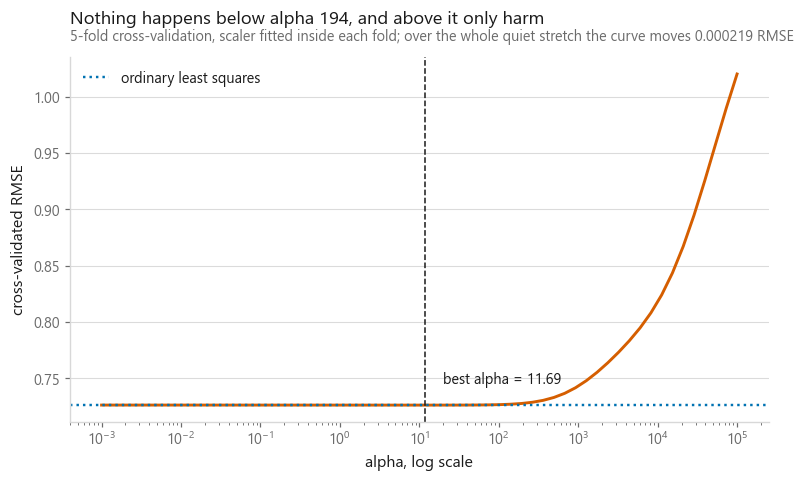

In [5]:
from sklearn.linear_model import RidgeCV

scores = [rmse(make_pipeline(StandardScaler(), Ridge(alpha=a)), X_collinear.values)
          for a in alphas]
best = int(np.argmin(scores))
ols_score = rmse(make_pipeline(StandardScaler(), LinearRegression()), X_collinear.values)

fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.plot(alphas, scores, color=style.HIGHLIGHT)
ax.axvline(alphas[best], color=style.INK, ls="--", lw=1)
ax.axhline(ols_score, color=style.PALETTE[0], ls=":", lw=1.6, label="ordinary least squares")
ax.annotate(f"best alpha = {alphas[best]:.2f}", xy=(alphas[best], scores[best]),
            xytext=(12, 14), textcoords="offset points", fontsize=9.5, color=style.INK)
ax.set_xscale("log")
ax.set_xlabel("alpha, log scale")
ax.set_ylabel("cross-validated RMSE")
ax.legend()

scores = np.array(scores)
quiet = alphas <= 100
departs = alphas[int(np.argmax(scores > ols_score + 0.001))]

style.title(
    ax,
    f"Nothing happens below alpha {departs:.0f}, and above it only harm",
    f"5-fold cross-validation, scaler fitted inside each fold; over the whole "
    f"quiet stretch the curve moves {scores[quiet].max() - scores[quiet].min():.6f} RMSE",
)
style.save(fig, FIG / "fig-03-choosing-alpha.png")

print(f"best alpha         : {alphas[best]:.3f}")
print(f"RMSE at that alpha : {scores[best]:.6f}")
print(f"RMSE for plain OLS : {ols_score:.6f}")
print(f"the best alpha beats plain OLS by {ols_score - scores[best]:.6f} RMSE")
print(f"across every alpha up to 100 the RMSE spans only "
      f"{scores[quiet].max() - scores[quiet].min():.6f}, and never leaves OLS by more "
      f"than {np.abs(scores[quiet] - ols_score).max():.6f}")
print(f"first alpha whose RMSE is 0.001 worse than OLS: {departs:.3f}")
print(f"RMSE at alpha=1e5  : {scores[-1]:.4f}   <- so much penalty the model is nearly a constant")

The left half of this chart is flat, and it is flat *on* the ordinary least
squares line, not above it. There is no unstable low-alpha region here to point
at. Across every alpha from 0.001 to 100 the cross-validated RMSE moves by
0.000219 in total and never departs from the OLS reference by more than
0.000184. The alpha that cross-validation picks, 11.690, beats plain least
squares by 0.000035 RMSE, which in units of a hundred thousand dollars is about
three dollars fifty.

The curve does not start climbing until alpha 194.149. So the shape of this
figure is not the usual U with a minimum in the middle. It is a flat line
followed by a cliff, and everything interesting about ridge on this dataset
happens in the coefficients rather than in the score. Section 3 already said as
much: the purchase is stability, not accuracy, and this chart is the same finding
from the other direction.

Two conditions have to hold before you see a real U here: enough features
relative to rows that unregularised least squares genuinely overfits, and a
penalty small enough to trim variance without eating signal. 20,640 rows against
9 columns satisfies neither. Choosing alpha by cross-validation is still the
right procedure; it just has nothing to find on this data, and a procedure that
reports "nothing to find" is working correctly.

### Scaling, and when it actually bites

The penalty $\alpha\|w\|^2$ treats every weight equally, so a feature measured in
small units, which therefore needs a large weight to have any effect, gets
punished for its units rather than its usefulness.

That is the theory, and testing it took two attempts. At `alpha=1` on 20,640 rows
the data term so outweighs the penalty that scaling changes nothing measurable,
even after I deliberately re-expressed two columns in absurd units. The effect
only appears once `alpha` is large enough to actually bite.

In [6]:
# Re-express Population in millions and MedInc in dollars. No information changes,
# only the numbers the penalty sees.
X_mixed = X_collinear.copy()
X_mixed["Population"] = X_mixed["Population"] / 1e6
X_mixed["MedInc"] = X_mixed["MedInc"] * 1e4

print(f"{'alpha':>8} {'unscaled':>10} {'scaled':>9} {'cost':>9}")
for a in [1, 100, 10_000, 1_000_000]:
    bare = -cross_val_score(Ridge(alpha=a), X_mixed.values, y, cv=folds,
                            scoring="neg_root_mean_squared_error", n_jobs=-1).mean()
    piped = rmse(make_pipeline(StandardScaler(), Ridge(alpha=a)), X_mixed.values)
    print(f"{a:>8} {bare:>10.4f} {piped:>9.4f} {bare - piped:>+9.4f}")

   alpha   unscaled    scaled      cost


       1     0.7263    0.7263   -0.0001


     100     0.7260    0.7267   -0.0007


   10000     0.7682    0.8178   -0.0495


 1000000     0.8084    1.1355   -0.3271


At `alpha=1` the two agree to four decimals. By `alpha=10,000` they differ by
five points of RMSE, and **the unscaled version is the better one**, which is
the opposite of the moral I expected to write.

The reason is worth following, because it is the actual argument for scaling.
I inflated `MedInc` by a factor of 10,000. Its coefficient therefore had to
shrink by the same factor to produce the same prediction, and a tiny coefficient
is nearly free under an $\alpha\|w\|^2$ penalty. So the unscaled model got to keep
the single most predictive feature almost unregularised while the penalty
flattened everything else. It scored better **by accident**, because of a unit I
chose arbitrarily.

That is the problem, not a defence. **Without scaling, your choice of units
decides which features the penalty protects.** Express income in dollars and it
survives; express it in tens of thousands and it gets shrunk with everything
else. Same data, same model, different answer, for a reason that has nothing to
do with the world.

Scaling does not promise a better score. It promises that the penalty is
responding to how useful a feature is rather than to what you happened to measure
it in. That is why it is not optional, and the accidental win above is a good
argument for it rather than against.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Features are correlated; you have many features relative to rows; you want stable coefficients you can interpret |
| **Prefer Lasso when** | You want features actually removed. Ridge never sets a weight to zero |
| **Scaling needed** | Yes, always. The penalty is unit-blind |
| **Main dial** | `alpha`. Larger means more shrinkage. `RidgeCV` picks it efficiently |
| **Free bonus** | Always has a unique solution, even with perfectly collinear features, where OLS has none |
| **Watch out** | Choose `alpha` inside cross-validation, not by peeking at the test set |

## What to remember

1. Ridge adds $\alpha\|w\|^2$ to squared error, so large weights must earn their size.
2. **On this dataset ridge bought no accuracy**: every RMSE matched to four
   decimals. What it bought was coefficients thirty times more stable across
   resamples. That is a different, narrower, and still useful claim.
3. The dramatic cancelling weights of the textbook, +1000 against -997, need
   *scarce* data. With
   20,640 rows and 9 columns, collinearity dented stability and left accuracy alone.
4. The closed form adds $\alpha$ down the diagonal, which guarantees a solution
   even when least squares has none.
5. The **length** of the weight vector shrinks monotonically with alpha, and no
   coefficient ever reaches exactly zero. That is the L2 signature. Individual
   coefficients are free to rise and to change sign along the way, and 6 of the 9
   here did, because ridge reshuffles weight between correlated features while
   the total shrinks.
6. Without scaling, your choice of units decides which features the penalty
   protects. In the sweep above, inflating income by 10,000 shielded it from
   regularisation and *improved* the score, by accident. Scale so the penalty
   responds to usefulness rather than to units.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [02-05 Lasso regression](../05-lasso-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#RidgeRegression` `#Regularization` `#L2` `#LinearRegression`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#Multicollinearity`